# Train MobileNetV2 (GitHub repo) on your dataset

Pick one of these official PyTorch repos and train **the actual MobileNetV2** end‑to‑end on your images:

- **d-li14/mobilenetv2.pytorch** (training script & multiple width multipliers)  
- **tonylins/pytorch-mobilenet-v2** (clean MobileNetV2 module)

**Dataset expected:**
```
model/datasets/
  train/{fresh,not_fresh}/{species}/*.jpg
  validation/{fresh,not_fresh}/{species}/*.jpg
  test/{fresh,not_fresh}/{species}/*.jpg   # optional
```

We flatten `(freshness, species)` into one label like `fresh__bigeye_scad` so we can use the standard ImageNet training code.

## 0) Choose repo (`REPO`): `'dli14'` or `'tonylins'`

In [1]:
REPO = 'dli14'  # <-- change to 'tonylins' if you prefer that implementation
EPOCHS = 40     # try 120–150 later for best accuracy
LR = 0.05
BATCH = 32
INPUT_SIZE = 224
NUM_WORKERS = 0

## 1) Install PyTorch (skip if already installed)

In [2]:
import sys, subprocess
def pipi(args):
    print('> pip', ' '.join(args))
    subprocess.check_call([sys.executable, '-m', 'pip'] + args)
try:
    import torch, torchvision
    print('Torch/Torchvision already installed')
except Exception as e:
    print('Installing PyTorch CUDA 11.8 wheels...')
    pipi(['install','torch','torchvision','torchaudio','--index-url','https://download.pytorch.org/whl/cu118'])

Torch/Torchvision already installed


## 2) Clone the chosen repo

In [3]:
import subprocess, os
if REPO == 'dli14':
    url = 'https://github.com/d-li14/mobilenetv2.pytorch.git'
    target = 'mobilenetv2.pytorch'
elif REPO == 'tonylins':
    url = 'https://github.com/tonylins/pytorch-mobilenet-v2.git'
    target = 'pytorch-mobilenet-v2'
else:
    raise ValueError("REPO must be 'dli14' or 'tonylins'")

if not os.path.exists(target):
    subprocess.check_call(['git', 'clone', url])
else:
    print('Repo already cloned:', target)

Repo already cloned: mobilenetv2.pytorch


## 3) Split datasets (multitask splitter inside notebook)

In [4]:
# split_multitask.py
# Usage (from model/source_code):
#   python split_multitask.py --src ../datasets/_raw --dst ../datasets --train 0.6 --val 0.2 --test 0.2 --clean --move --seed 123
from __future__ import annotations
from pathlib import Path
import argparse, random, shutil, math

ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect(src_root: Path) -> dict[tuple[str, str], list[Path]]:
    buckets: dict[tuple[str,str], list[Path]] = {}
    if not src_root.exists():
        raise SystemExit(f"Source not found: {src_root}")
    for freshness_dir in src_root.iterdir():  # fresh / not_fresh
        if not freshness_dir.is_dir(): 
            continue
        f_name = freshness_dir.name
        for species_dir in freshness_dir.iterdir():  # species
            if not species_dir.is_dir():
                continue
            s_name = species_dir.name
            key = (f_name, s_name)
            buckets.setdefault(key, [])
            for p in species_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in ALLOWED:
                    buckets[key].append(p)
    return buckets

def split_counts(n: int, r_train: float, r_val: float, r_test: float) -> tuple[int,int,int]:
    if not (0.999 <= (r_train + r_val + r_test) <= 1.001):
        raise ValueError("Splits must sum to 1.0")
    base = [math.floor(n * r) for r in (r_train, r_val, r_test)]
    rem = n - sum(base)
    # distribute remaining items by largest fractional parts
    fracs = [n * r - b for r, b in zip((r_train, r_val, r_test), base)]
    order = sorted(range(3), key=lambda i: fracs[i], reverse=True)
    for i in order[:rem]:
        base[i] += 1
    return tuple(base)

def _clear_dir(d: Path):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

def place(files: list[Path], dst_root: Path, subset: str, f_name: str, s_name: str, move: bool):
    out_dir = dst_root / subset / f_name / s_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for src in files:
        dst = out_dir / src.name
        if move:
            shutil.move(str(src), str(dst))
        else:
            shutil.copy2(str(src), str(dst))

def main():
    ap = argparse.ArgumentParser(description="Split dataset into train/validation/test.")
    ap.add_argument("--src", default="datasets/_raw", help="root of unsplit data")
    ap.add_argument("--dst", default="datasets", help="destination datasets root")
    ap.add_argument("--train", type=float, default=0.70)
    ap.add_argument("--val",   type=float, default=0.10)
    ap.add_argument("--test",  type=float, default=0.20)
    ap.add_argument("--seed",  type=int, default=123)
    ap.add_argument("--move",  action="store_true", help="move files instead of copy")
    ap.add_argument("--clean", action="store_true", help="wipe existing train/validation/test first")
    args, _ = ap.parse_known_args()

    base = Path.cwd()
    src_root = (base / args.src).resolve()
    dst_root = (base / args.dst).resolve()

    if args.clean:
        for s in ("train","validation","test"):
            _clear_dir(dst_root / s)
    else:
        for s in ("train","validation","test"):
            (dst_root / s).mkdir(parents=True, exist_ok=True)

    random.seed(args.seed)

    buckets = collect(src_root)
    if not buckets:
        raise SystemExit(f"No images found under {src_root}")

    total = 0
    print("Splitting per (freshness, species):")
    for (f_name, s_name), files in sorted(buckets.items()):
        files = [p for p in files if p.suffix.lower() in ALLOWED]
        random.shuffle(files)
        n = len(files)
        t, v, te = split_counts(n, args.train, args.val, args.test)

        train_files = files[:t]
        val_files   = files[t:t+v]
        test_files  = files[t+v:t+v+te]

        place(train_files, dst_root, "train",      f_name, s_name, args.move)
        place(val_files,   dst_root, "validation", f_name, s_name, args.move)
        place(test_files,  dst_root, "test",       f_name, s_name, args.move)

        total += n
        print(f"  {f_name:10s} / {s_name:25s} -> "
              f"train {len(train_files):4d}, val {len(val_files):4d}, test {len(test_files):4d}  (total {n})")

    print(f"\nDone. Processed {total} files. Output: {dst_root}")

if __name__ == "__main__":
    main()


Splitting per (freshness, species):
  fresh      / bigeye_scad               -> train  107, val   15, test   31  (total 153)
  fresh      / country_maiden            -> train   33, val    5, test   10  (total 48)
  fresh      / fringescale_sardinella    -> train   89, val   13, test   25  (total 127)
  fresh      / indian_mackerel           -> train   81, val   12, test   23  (total 116)
  fresh      / mackerel_scad             -> train   74, val   10, test   21  (total 105)
  fresh      / yellowfin_tuna            -> train   12, val    2, test    4  (total 18)
  not_fresh  / bigeye_scad               -> train   94, val   13, test   27  (total 134)
  not_fresh  / country_maiden            -> train   43, val    6, test   13  (total 62)
  not_fresh  / fringescale_sardinella    -> train  122, val   17, test   35  (total 174)
  not_fresh  / indian_mackerel           -> train   89, val   13, test   25  (total 127)
  not_fresh  / mackerel_scad             -> train  229, val   33, test   66  

## 4) Deduper using Perceptual Hash (pHash)

In [5]:
# === IMAGE DEDUPLICATION (pHash / histogram / embedding) ===
# Works with your layout: model/datasets/{train,validation,test}/{fresh,not_fresh}/{species}/*.jpg

import os, shutil, math, json
from pathlib import Path
from collections import defaultdict

# --------- CONFIG ---------
ROOT = Path("datasets/")         # where your raw split folders live
SPLITS = ["train","validation","test"] # which splits to scan
GROUP_MODE = "class"  # "class" -> dedupe within each (freshness/species) across all splits,
                      # "split" -> dedupe inside each split separately,
                      # "global" -> dedupe across all images together (be careful)
METHOD = "phash"      # "phash" (default), "hist", "embed"
DRY_RUN = False        # True -> only report; False -> move/delete duplicates
ACTION = "move"       # "move" -> move dups to ROOT/_duplicates/...,  "delete" -> remove them
# thresholds
PHASH_HAMMING = 5     # 0..64  (lower = stricter)
HIST_SIM = 0.995      # cosine similarity threshold (0..1, higher = stricter)
EMBED_SIM = 0.996     # cosine similarity threshold for CNN embeddings

OUT = Path("model/models") if Path("model").exists() else Path("models")
OUT.mkdir(parents=True, exist_ok=True)
REPORT = OUT/"duplicates.csv"
DUPS_DIR = ROOT/"_duplicates"

# --------- UTILS ---------
def list_images(root: Path):
    exts = {".jpg",".jpeg",".png",".bmp",".webp"}
    for p in root.rglob("*"):
        if p.suffix.lower() in exts:
            yield p

def group_key(p: Path):
    # Expect: .../<split>/<fresh|not_fresh>/<species>/image.jpg
    parts = p.parts
    if GROUP_MODE == "global":
        return "ALL"
    if GROUP_MODE == "split":
        # group by split/freshness/species folder path
        # find split index
        for s in SPLITS:
            if s in parts:
                i = parts.index(s)
                return "/".join(parts[i:i+3]) if len(parts) >= i+3 else "/".join(parts[i:])
        return "unknown"
    # default: class (freshness/species) across *all* splits
    # find freshness + species no matter which split
    for s in SPLITS:
        if s in parts:
            i = parts.index(s)
            if len(parts) >= i+3:
                return "/".join(parts[i+1:i+3])  # e.g. 'fresh/bigeye_scad'
    return "unknown"

def prefer_keep(a: Path, b: Path):
    # Keep order: train > validation > test, then shorter filename
    rank = { "train":0, "validation":1, "test":2 }
    def key(p: Path):
        sp = next((s for s in SPLITS if s in p.parts), "zzz")
        return (rank.get(sp, 9), len(p.name))
    return a if key(a) <= key(b) else b

def ensure_deps():
    import importlib, sys, subprocess, os
    def pip_install(*pkgs):
        # short temp/cache paths help on Windows
        Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
        os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
        subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir",*pkgs])
    # PIL
    try: import PIL  # noqa
    except: pip_install("Pillow")
    if METHOD == "phash":
        try: import imagehash  # noqa
        except: pip_install("imagehash")
    if METHOD == "embed":
        try:
            import torch, torchvision  # noqa
        except:
            pip_install("torch","torchvision","torchaudio","--index-url","https://download.pytorch.org/whl/cpu")

ensure_deps()

# --------- SIMILARITY BACKENDS ---------
from PIL import Image, UnidentifiedImageError
import numpy as np

def cosine(a, b, eps=1e-8):
    return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + eps))

def sim_phash(paths):
    import imagehash
    hashes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                h = imagehash.phash(im.convert("RGB"))  # 64-bit
            hashes.append(int(str(h), 16))
        except Exception:
            hashes.append(None)
    # O(n^2) grouping
    n = len(paths); used=set(); groups=[]
    for i in range(n):
        if hashes[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if hashes[j] is None or j in used: continue
            # hamming distance between two 64-bit ints
            d = (hashes[i] ^ hashes[j]).bit_count()
            if d <= PHASH_HAMMING:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))  # score optional
    return groups

def sim_hist(paths):
    def histvec(p):
        try:
            with Image.open(p) as im:
                hsv = im.convert("HSV")
                h,s,v = hsv.split()
                h1,_ = np.histogram(np.array(h).ravel(), bins=32, range=(0,255))
                s1,_ = np.histogram(np.array(s).ravel(), bins=32, range=(0,255))
                v1,_ = np.histogram(np.array(v).ravel(), bins=32, range=(0,255))
                vec = np.concatenate([h1,s1,v1]).astype(np.float32)
                vec /= (np.linalg.norm(vec)+1e-8)
                return vec
        except Exception:
            return None
    vecs = [histvec(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= HIST_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

def sim_embed(paths):
    import torch, torchvision
    from torchvision import transforms
    # MobileNetV2 backbone -> 1280-d embedding
    weights = torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
    net = torchvision.models.mobilenet_v2(weights=weights)
    net.classifier = torch.nn.Identity()
    net.eval()
    tfm = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                              transforms.ToTensor(), transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])
    def emb(p):
        try:
            with Image.open(p) as im:
                x = tfm(im.convert("RGB")).unsqueeze(0)
            with torch.no_grad():
                e = net(x).squeeze(0).numpy().astype(np.float32)
            e /= (np.linalg.norm(e)+1e-8)
            return e
        except Exception:
            return None
    vecs = [emb(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= EMBED_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

METHOD_FN = {"phash": sim_phash, "hist": sim_hist, "embed": sim_embed}[METHOD]

# --------- SCAN & GROUP ---------
# Build class groups (freshness/species) across all splits
buckets = defaultdict(list)
for split in SPLITS:
    base = ROOT/split
    if not base.exists(): continue
    for p in list_images(base):
        buckets[group_key(p)].append(p)

total_imgs = sum(len(v) for v in buckets.values())
print(f"Scanning {len(buckets)} groups with {total_imgs} images using method='{METHOD}'")

# --------- FIND DUPLICATES & REPORT ---------
rows = [["group","keeper","duplicate","method","note"]]
dups = []
for gname, files in buckets.items():
    if len(files) < 2: continue
    # stable order: prefer keep train > validation > test
    files = sorted(files, key=lambda p: (["train","validation","test"].index(next((s for s in SPLITS if s in p.parts), "test")) if any(s in p.parts for s in SPLITS) else 9, p.name))
    groups = METHOD_FN(files)
    for idxs, _ in groups:
        # Decide keeper inside the group (by priority)
        keeper = files[idxs[0]]
        for j in idxs[1:]:
            dup = files[j]
            dups.append((gname, keeper, dup))

# Save report
for g, keep, dup in dups:
    rows.append([g, str(keep), str(dup), METHOD, ""])
REPORT.write_text("\n".join([",".join(map(str,r)) for r in rows]), encoding="utf-8")
print(f"Found {len(dups)} duplicates. Report -> {REPORT.resolve()}")

# --------- ACT ON DUPLICATES ---------
if DRY_RUN or not dups:
    print("DRY_RUN=True (no files moved/deleted). Set DRY_RUN=False to apply.")
else:
    DUPS_DIR.mkdir(parents=True, exist_ok=True)
    for g, keep, dup in dups:
        if ACTION == "delete":
            try: dup.unlink()
            except Exception as e: print("fail delete:", dup, e)
        else:
            # move to _duplicates, mirroring relative path
            rel = dup.relative_to(ROOT)
            dest = DUPS_DIR/rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            try: shutil.move(str(dup), str(dest))
            except Exception as e: print("fail move:", dup, "->", dest, e)
    print(f"Applied ACTION='{ACTION}'. Duplicates moved to {DUPS_DIR} (or deleted).")


Scanning 12 groups with 1407 images using method='phash'
Found 44 duplicates. Report -> C:\aziztebbeng\2025-CP_Fishfresh\model\model\models\duplicates.csv
Applied ACTION='move'. Duplicates moved to datasets\_duplicates (or deleted).


## 5) Draws distribution bar charts of dataset

[skip] missing split: datasets\testing
Saved counts -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\dataset_counts.csv
Loaded duplicate removals from: C:\aziztebbeng\2025-CP_Fishfresh\model\models\duplicates.csv
Total removed duplicates: 19


<Figure size 960x720 with 0 Axes>

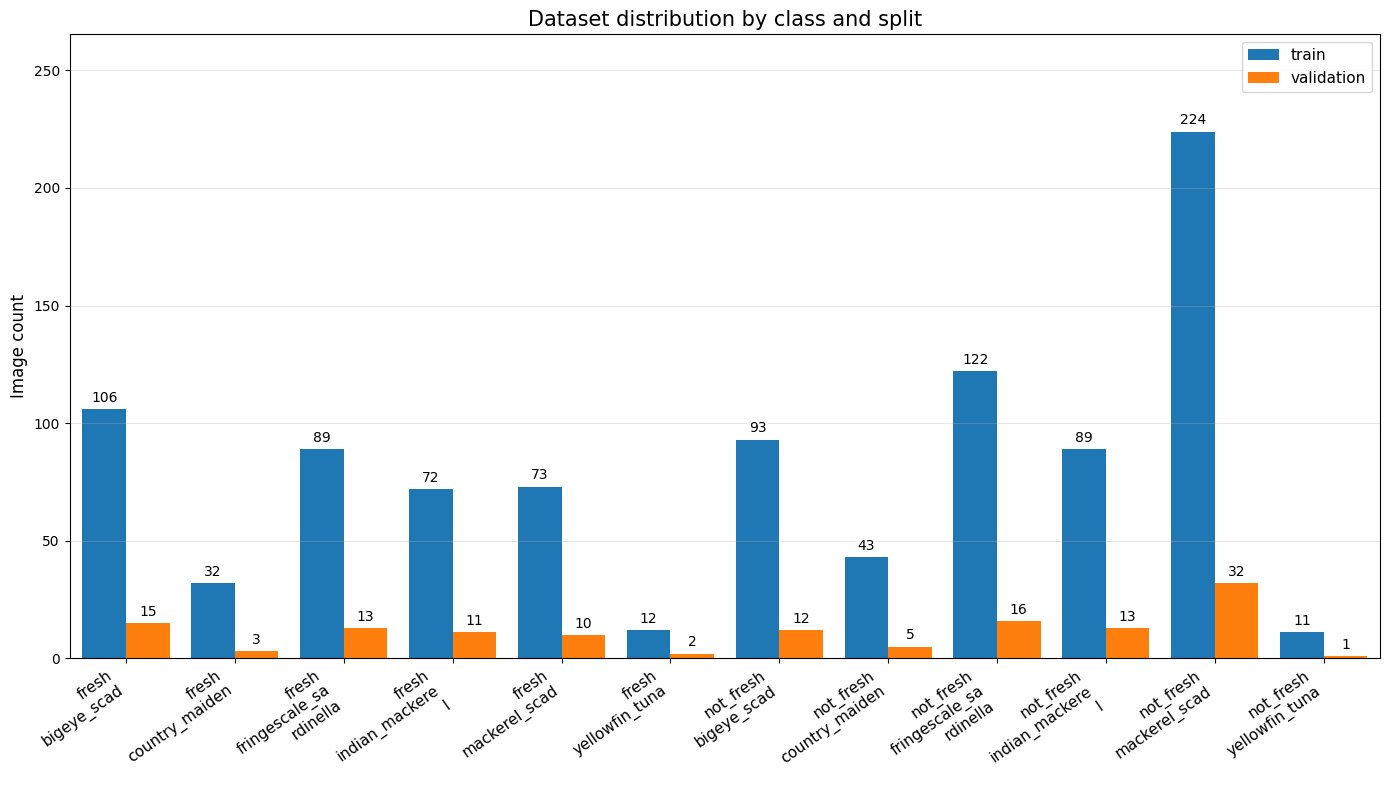

Loaded duplicates from: C:\aziztebbeng\2025-CP_Fishfresh\model\model\models\duplicates.csv
CSV removed total: 44


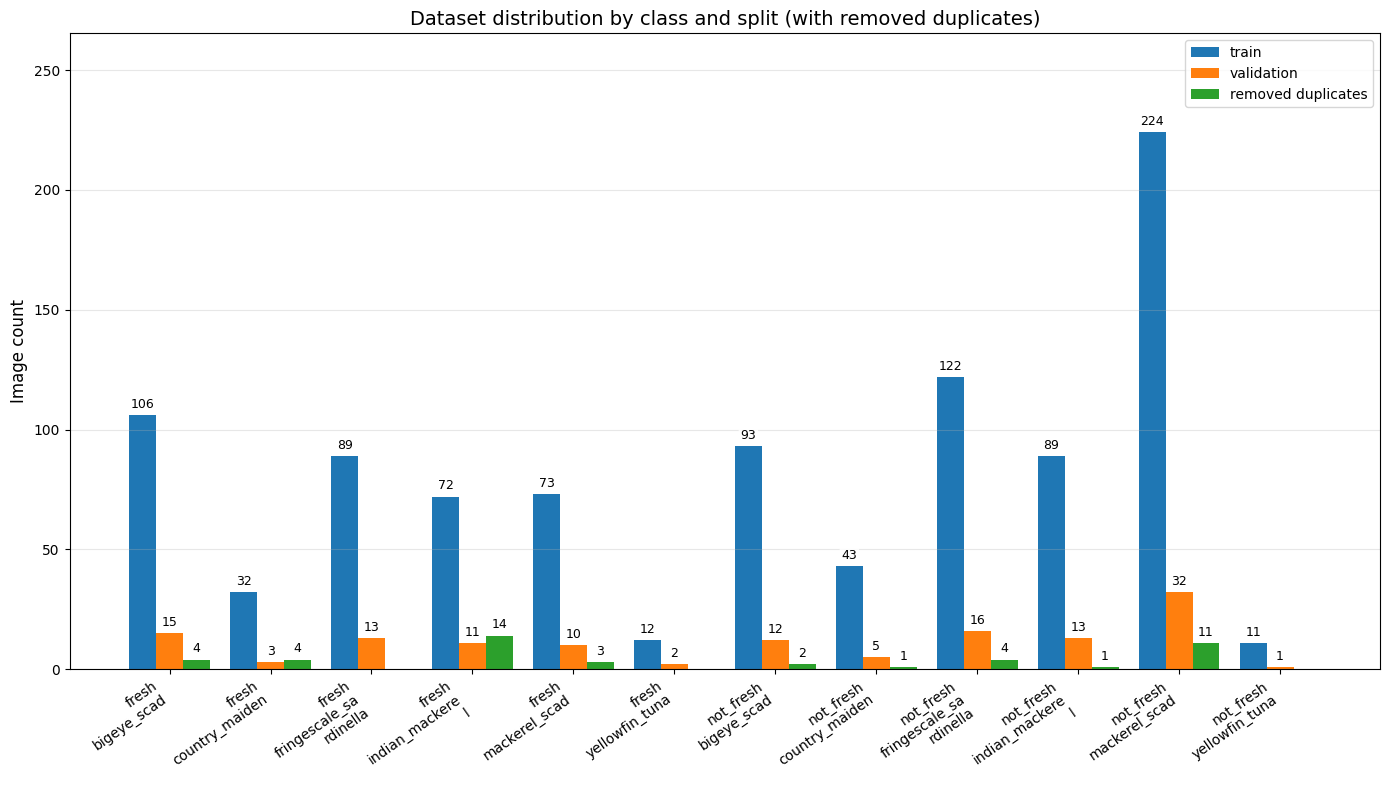

Removed shown in chart (sum): 44
First 6 class/removed: [('fresh__bigeye_scad', 4), ('fresh__country_maiden', 4), ('fresh__fringescale_sardinella', 0), ('fresh__indian_mackerel', 14), ('fresh__mackerel_scad', 3), ('fresh__yellowfin_tuna', 0)]


In [6]:
# === CLEANED DATASET DISTRIBUTION CHARTS (readable labels + exact numbers) ===
# Works with: datasets/{train,validation,testing}/{fresh|not_fresh}/{species}/*.jpg
from pathlib import Path
import os, sys, subprocess, textwrap

# --- CONFIG ---
ROOT   = Path("datasets")                   # base dataset folder
SPLITS = ["train","validation","testing"]   # split names present on disk
SAVE_DIR = Path("models") if Path("models").exists() else Path("model/models")

# --- ensure deps ---
try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas","numpy"])
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

# High-DPI for crisp text
plt.gcf().set_dpi(150)

# --- helpers ---
def wrap_class_label(c, width=14):
    """Turn 'fresh__indian_mackerel' -> 'fresh\nindian_mackerel' and wrap long species."""
    parts = c.split("__", 1)
    if len(parts) == 2:
        fresh, species = parts
        species_wrapped = "\n".join(textwrap.wrap(species, width))
        return f"{fresh}\n{species_wrapped}"
    return "\n".join(textwrap.wrap(c, width))

def add_labels_on_bars(bars, values, fontsize=10, pad=3):
    """Add integer labels on top of vertical bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        h = rect.get_height()
        x = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (x, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

def add_labels_on_barh(bars, values, fontsize=10, pad=3):
    """Add integer labels at the end of horizontal bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        w = rect.get_width()
        y = rect.get_y() + rect.get_height()/2
        plt.annotate(
            f"{int(v)}",
            (w, y),
            xytext=(pad, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

# --- count images per class & split ---
EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}
rows = []
for split in SPLITS:
    base = ROOT / split
    if not base.exists():
        print(f"[skip] missing split: {base}")
        continue
    for freshness in ["fresh","not_fresh"]:
        fdir = base / freshness
        if not fdir.exists():
            continue
        for species_dir in sorted([p for p in fdir.iterdir() if p.is_dir()]):
            n = sum(1 for p in species_dir.rglob("*") if p.suffix.lower() in EXTS)
            rows.append({"class": f"{freshness}__{species_dir.name}", "split": split, "count": n})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No images found. Check ROOT/SPLITS and your folder structure.")

wide = (
    df.pivot_table(index="class", columns="split", values="count", aggfunc="sum")
      .fillna(0).astype(int)
      .sort_index()
)

SAVE_DIR.mkdir(parents=True, exist_ok=True)
(wide.to_csv(SAVE_DIR/"dataset_counts.csv"))
print("Saved counts ->", (SAVE_DIR/"dataset_counts.csv").resolve())

# --- optional: duplicates removed (if report exists) ---
dup_csv = SAVE_DIR/"duplicates.csv"
dup_counts = None
if dup_csv.exists():
    try:
        ddf = pd.read_csv(dup_csv)
        if "group" in ddf.columns:
            # normalize: convert backslashes, then replace "/" with "__"
            ddf["class_norm"] = (
                ddf["group"].astype(str)
                   .str.replace("\\\\", "/", regex=True)
                   .str.replace("/", "__", regex=False)
            )
            dup_counts = (
                ddf.groupby("class_norm").size()
                   .rename("removed")
                   .to_frame()
            )
            dup_counts.index.name = "class"
            print("Loaded duplicate removals from:", dup_csv.resolve())
            print("Total removed duplicates:", int(dup_counts["removed"].sum()))
        else:
            print("duplicates.csv missing 'group' column; no overlay will be shown.")
    except Exception as e:
        print("Could not read duplicates.csv:", e)
# -------------------------------
# Chart 1: Grouped bars per split
# -------------------------------
classes = wide.index.tolist()
labels_wrapped = [wrap_class_label(c, width=14) for c in classes]
present_splits = [s for s in SPLITS if s in wide.columns]
n_classes = len(classes)
n_splits  = max(1, len(present_splits))
x = np.arange(n_classes)
bar_w = 0.8 / n_splits

fig_w = max(14, n_classes * 1.0)
fig_h = 8
plt.figure(figsize=(fig_w, fig_h))
containers = []

for k, split in enumerate(present_splits):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    bars = plt.bar(xs, wide[split].values, width=bar_w, label=split)
    containers.append((bars, wide[split].values))

# labels on bars
for bars, vals in containers:
    add_labels_on_bars(bars, vals, fontsize=10, pad=3)

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=11)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split", fontsize=15)
plt.legend(fontsize=11)
plt.grid(axis="y", alpha=0.3)
plt.margins(x=0.01)

# y-axis headroom so labels don’t clip
ymax = max(wide[split].max() for split in present_splits) if present_splits else 0
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# -------------------------------------------
# Chart 2 (FIXED): grouped bars + a 3rd "removed duplicates" bar
# - picks the correct duplicates.csv
# - unions classes so removed-only classes still appear
# -------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import time

def _pick_dup_csv():
    cands = [
        Path("models/duplicates.csv"),
        Path("model/models/duplicates.csv"),
        Path("model/model/models/duplicates.csv"),
    ]
    cands = [p for p in cands if p.exists()]
    if not cands:
        return None
    # choose the most recently modified
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

# 1) Rebuild 'wide' if needed (assumes you already have it from Chart 1)
#    wide: index=class ("fresh__species"), columns=[train, validation, testing], values=int

# 2) Load duplicates.csv (most recent in common locations)
dup_csv = _pick_dup_csv()
dup_counts = None
if dup_csv is not None:
    ddf = pd.read_csv(dup_csv)
    def _norm_group(g: str) -> str:
        s = str(g).replace("\\", "/").replace("__", "/")
        parts = [p for p in s.split("/") if p]
        if len(parts) >= 2:
            return f"{parts[-2]}__{parts[-1]}"
        return s.replace("/", "__")
    if "group" in ddf.columns:
        ddf["class_norm"] = ddf["group"].map(_norm_group)
        dup_counts = (
            ddf.groupby("class_norm").size().rename("removed").to_frame()
        )
        dup_counts.index.name = "class"
        print("Loaded duplicates from:", dup_csv.resolve())
        print("CSV removed total:", int(dup_counts["removed"].sum()))
    else:
        print("duplicates.csv missing 'group' column; no removed bar will be shown.")
else:
    print("No duplicates.csv found in expected locations.")

# 3) Build the x-axis class list as a UNION (bars also for classes with zero left)
classes_all = set(wide.index.tolist())
if dup_counts is not None:
    classes_all |= set(dup_counts.index.tolist())
classes = sorted(classes_all)

# reindex 'wide' to include empty classes as zeros
present_splits = [s for s in SPLITS if s in wide.columns]
wide = wide.reindex(classes).fillna(0).astype(int)

# vector aligned with classes for removed
dup_vec = np.zeros(len(classes), dtype=int)
if dup_counts is not None:
    dup_vec = dup_counts.reindex(classes).fillna(0)["removed"].astype(int).values

# 4) Draw grouped bars: train/validation/[…]/removed
x = np.arange(len(classes))
bar_names = present_splits + ["removed"]
n_bars = len(bar_names)
bar_w = 0.8 / n_bars

plt.figure(figsize=(max(14, len(classes) * 1.0), 8))
bar_containers = []

for k, name in enumerate(bar_names):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    if name == "removed":
        vals = dup_vec
        bars = plt.bar(xs, vals, width=bar_w, label="removed duplicates")
    else:
        vals = wide[name].values if name in wide.columns else np.zeros(len(classes), dtype=int)
        label_name = "test" if name == "testing" else name
        bars = plt.bar(xs, vals, width=bar_w, label=label_name)
    bar_containers.append((bars, vals))

def _add_labels(bars, vals, fontsize=9, pad=3):
    for rect, v in zip(bars, vals):
        h = rect.get_height()
        if h <= 0: 
            continue
        cx = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (cx, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
        )

# annotate every bar
for bars, vals in bar_containers:
    _add_labels(bars, vals)

# x labels
def wrap_label(c, width=14):
    a = c.split("__", 1)
    if len(a) == 2:
        return a[0] + "\n" + "\n".join(pd.Series([a[1]]).str.wrap(width).iloc[0].split("\n"))
    return c
labels_wrapped = [wrap_label(c, 14) for c in classes]

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=10)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split (with removed duplicates)", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=10)

# headroom
ymax = 0
for _, vals in bar_containers:
    if len(vals):
        ymax = max(ymax, int(np.max(vals)))
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# 5) Sanity checks
print("Removed shown in chart (sum):", int(dup_vec.sum()))
print("First 6 class/removed:", list(zip(classes[:6], dup_vec[:6])))



## 6) (Datasets Splitting) Flatten dataset to ImageFolder layout

In [7]:
# 3) Flatten dataset to ImageFolder (robust paths)
from pathlib import Path
import shutil, json

# ---- Auto-detect where the 'model/' folder is relative to this notebook ----
if Path('datasets/train').exists():            # prefer root
    MODEL_DIR = Path('.')
elif Path('model/datasets/train').exists():    # fallback
    MODEL_DIR = Path('model')
else:
    # last resort: search upwards
    cand = [p.parent for p in Path.cwd().rglob('datasets/train')]
    if cand:
        MODEL_DIR = cand[0]
    else:
        raise SystemExit("Couldn't find 'datasets/train'. Set MODEL_DIR manually.")

print("MODEL_DIR ->", MODEL_DIR.resolve())

SRC = MODEL_DIR / 'datasets'                    # expects train/, validation/, (test/)
DST = MODEL_DIR / 'pytorch_imagenet'            # will create train/, val/, test/
DST.mkdir(parents=True, exist_ok=True)

def flatten_split(split_name, out_name):
    src = SRC / split_name
    out = DST / out_name
    if not src.exists():
        print(f"[skip] {src} not found")
        return False
    out.mkdir(parents=True, exist_ok=True)
    copied = 0
    for freshness in ['fresh', 'not_fresh']:
        base = src / freshness
        if not base.exists():
            print(f"[warn] missing {base}")
            continue
        for sp_dir in base.iterdir():
            if not sp_dir.is_dir(): 
                continue
            cls = f"{freshness}__{sp_dir.name}"
            out_cls = out / cls
            out_cls.mkdir(parents=True, exist_ok=True)
            for img in sp_dir.rglob('*'):
                if img.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}:
                    shutil.copy2(img, out_cls / img.name)
                    copied += 1
    print(f"[done] {split_name} -> {out}  (copied {copied} files)")
    return copied > 0

ok_train = flatten_split('train', 'train')
ok_val   = flatten_split('validation', 'val')
ok_test  = flatten_split('test', 'test')

if not ok_train:
    raise SystemExit("No training images were copied. Check your source layout: "
                     "model/datasets/train/{fresh,not_fresh}/{species}/*.jpg")

# Build structured class list (Freshness + Species)
train_dir = DST / 'train'
all_classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
NUM_CLASSES = len(all_classes)

# Extract species from folder names like 'fresh__indian_mackerel'
species_classes = sorted(set(c.split('__')[1] for c in all_classes if '__' in c))
freshness_classes = ["Fresh", "Not Fresh"]

# Make sure models directory exists
(MODEL_DIR/'models').mkdir(parents=True, exist_ok=True)

# Create a structured JSON format
structured_classes = {
    "freshness_classes": freshness_classes,
    "species_classes": species_classes
}

# Save the structured version
classes_path = MODEL_DIR / 'models' / 'classes.json'
classes_path.write_text(json.dumps(structured_classes, indent=2))

# Optional: also save the flat list (if you still want it)
(MODEL_DIR/'models'/'classes_flat.json').write_text(json.dumps(all_classes, indent=2))

print(f"✅ Wrote structured classes.json to {classes_path.resolve()}")
print(f"Total Classes: {NUM_CLASSES}")
print("Species:", species_classes)


MODEL_DIR -> C:\aziztebbeng\2025-CP_Fishfresh\model
[done] train -> pytorch_imagenet\train  (copied 966 files)
[done] validation -> pytorch_imagenet\val  (copied 133 files)
[done] test -> pytorch_imagenet\test  (copied 264 files)
✅ Wrote structured classes.json to C:\aziztebbeng\2025-CP_Fishfresh\model\models\classes.json
Total Classes: 12
Species: ['bigeye_scad', 'country_maiden', 'fringescale_sardinella', 'indian_mackerel', 'mackerel_scad', 'yellowfin_tuna']


## 7) (Augmentation) Dataloaders & transforms with downsampling the training set

In [8]:
# === DATALOADERS with class-balanced downsampling (to smallest class or a target cap) ===
from pathlib import Path
from collections import Counter, defaultdict
import random
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ---- defaults if not already defined above ----
INPUT_SIZE   = int(globals().get('INPUT_SIZE', 224))
BATCH        = int(globals().get('BATCH', 16))
NUM_WORKERS  = int(globals().get('NUM_WORKERS', 0))  # Windows CPU: keep 0
PIN_MEMORY   = bool(globals().get('PIN_MEMORY', torch.cuda.is_available()))
SEED         = int(globals().get('SEED', 123))
# If you want to force an upper cap (e.g., 20 per class), set this to an int.
# If None, it will use the smallest class size automatically.
# TARGET_PER_CLASS = globals().get('TARGET_PER_CLASS', None)  # e.g., 20 or None
TARGET_PER_CLASS = 200  # e.g., 20 or None
# ------------------------------------------------------

# Find the flattened dataset root created by your "flatten" step
if Path('model/pytorch_imagenet/train').exists():
    DST = Path('model/pytorch_imagenet')
elif Path('pytorch_imagenet/train').exists():
    DST = Path('pytorch_imagenet')
else:
    raise SystemExit("Couldn't find the flattened dataset. Run the flatten step first "
                     "(it creates model/pytorch_imagenet/{train,val}).")

# Use 'val' if present; fall back to 'validation' if that’s what you have
VAL_DIR = DST/'val'
if not VAL_DIR.exists():
    alt = DST/'validation'
    if alt.exists():
        VAL_DIR = alt
    else:
        raise SystemExit(f"Missing validation split at {DST/'val'} (or {alt}).")

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
val_tfms = transforms.Compose([
    transforms.Resize(int(INPUT_SIZE*1.15)),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Build datasets
data = {
    'train': datasets.ImageFolder(DST/'train', transform=train_tfms),
    'val':   datasets.ImageFolder(VAL_DIR,     transform=val_tfms),
}

# Define CLASSES if not already set (handy for export later)
if 'CLASSES' not in globals():
    CLASSES = data['train'].classes

# ---------- helper functions ----------
def _labels_from_dataset(ds):
    if hasattr(ds, "targets"):
        return list(ds.targets)
    elif hasattr(ds, "samples"):
        return [y for _, y in ds.samples]
    raise AttributeError("Could not infer labels; expected torchvision ImageFolder-like dataset.")

def _count_subset(subset_like):
    if isinstance(subset_like, Subset):
        base = subset_like.dataset
        idxs = subset_like.indices
        if hasattr(base, "targets"):
            labels = [base.targets[i] for i in idxs]
        else:
            labels = [base.samples[i][1] for i in idxs]
        classes = getattr(base, "classes", None)
    else:
        labels  = _labels_from_dataset(subset_like)
        classes = getattr(subset_like, "classes", None)
    return Counter(labels), classes
 
# --- Show counts BEFORE ---
before_counts, _ = _count_subset(data['train'])
print("Before (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {before_counts.get(i,0)}")
print(f"Total before: {sum(before_counts.values())}\n")

# --- Use full training set (no balancing) ---
after_counts, _ = _count_subset(data['train'])
print("After (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {after_counts.get(i,0)}")
print(f"Total after: {sum(after_counts.values())}\n")

# --- Build loaders (train uses full dataset) ---
loaders = {
    'train': DataLoader(data['train'], batch_size=BATCH, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
    'val':   DataLoader(data['val'],   batch_size=BATCH, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
}

print("Using dataset root:", DST.resolve())
print("Train classes:", len(CLASSES),
      "  Train batches:", len(loaders['train']),
      "  Val batches:", len(loaders['val']))
print("INPUT_SIZE:", INPUT_SIZE, " BATCH:", BATCH, " NUM_WORKERS:", NUM_WORKERS, " PIN_MEMORY:", PIN_MEMORY)


Before (per class):
  fresh__bigeye_scad                  -> 106
  fresh__country_maiden               -> 32
  fresh__fringescale_sardinella       -> 89
  fresh__indian_mackerel              -> 72
  fresh__mackerel_scad                -> 73
  fresh__yellowfin_tuna               -> 12
  not_fresh__bigeye_scad              -> 93
  not_fresh__country_maiden           -> 43
  not_fresh__fringescale_sardinella   -> 122
  not_fresh__indian_mackerel          -> 89
  not_fresh__mackerel_scad            -> 224
  not_fresh__yellowfin_tuna           -> 11
Total before: 966

After (per class):
  fresh__bigeye_scad                  -> 106
  fresh__country_maiden               -> 32
  fresh__fringescale_sardinella       -> 89
  fresh__indian_mackerel              -> 72
  fresh__mackerel_scad                -> 73
  fresh__yellowfin_tuna               -> 12
  not_fresh__bigeye_scad              -> 93
  not_fresh__country_maiden           -> 43
  not_fresh__fringescale_sardinella   -> 122
  not_fresh__

## 8) Build model from the selected GitHub repo

In [9]:
# === BUILD MobileNetV2 (robust; uses real GitHub impl) ===
import importlib.util
from pathlib import Path
import torch, torch.nn as nn

# Defaults if not set above
REPO = str(globals().get('REPO', 'dli14')).lower()      # 'dli14' or 'tonylins'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Figure out class count
if 'NUM_CLASSES' in globals():
    NUM_CLASSES = int(NUM_CLASSES)
elif 'CLASSES' in globals():
    NUM_CLASSES = len(CLASSES)
elif 'data' in globals() and 'train' in data:
    NUM_CLASSES = len(data['train'].classes)
else:
    raise SystemExit("Can't determine NUM_CLASSES. Run the dataloaders cell first so CLASSES/data exist.")

def _load_module(py_path: Path, name: str):
    if not py_path.exists():
        raise SystemExit(f"Expected file not found: {py_path}\n"
                         f"Did you clone the repo? (git clone https://github.com/d-li14/mobilenetv2.pytorch) "
                         f"or (git clone https://github.com/tonylins/pytorch-mobilenet-v2)")
    spec = importlib.util.spec_from_file_location(name, py_path)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod

def build_mbv2(repo: str, num_classes: int):
    if repo == 'dli14':
        mod = _load_module(Path('mobilenetv2.pytorch/models/imagenet/mobilenetv2.py'), 'mbv2_dli14')
        model = mod.mobilenetv2(num_classes=num_classes)
    elif repo == 'tonylins':
        mod = _load_module(Path('pytorch-mobilenet-v2/MobileNetV2.py'), 'mbv2_tonylins')
        if hasattr(mod, 'mobilenet_v2'):
            try:
                model = mod.mobilenet_v2(num_classes=num_classes)
            except TypeError:
                # some versions ignore num_classes in ctor -> replace head manually
                model = mod.mobilenet_v2()
        else:
            model = mod.MobileNetV2(num_classes=num_classes)
        # Ensure classifier out_features == num_classes
        if hasattr(model, 'classifier'):
            if isinstance(model.classifier, nn.Sequential):
                last = model.classifier[-1]
                if isinstance(last, nn.Linear) and last.out_features != num_classes:
                    model.classifier[-1] = nn.Linear(last.in_features, num_classes)
            elif isinstance(model.classifier, nn.Linear) and model.classifier.out_features != num_classes:
                model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError("REPO must be 'dli14' or 'tonylins'")
    return model

model = build_mbv2(REPO, NUM_CLASSES).to(device)

# Print a tiny summary
head = None
if hasattr(model, 'classifier'):
    head = model.classifier[-1] if isinstance(model.classifier, nn.Sequential) else model.classifier
print(f"Built MobileNetV2 from repo='{REPO}'  -> num_classes={NUM_CLASSES}")
print("Final head:", type(head).__name__ if head else "N/A")

# (optional) sanity forward
with torch.no_grad():
    _ = model(torch.randn(1,3,224,224).to(device))
print("Sanity forward OK on", device)


Built MobileNetV2 from repo='dli14'  -> num_classes=12
Final head: Linear
Sanity forward OK on cpu


In [10]:
# Install tqdm from inside the notebook (Windows-safe temp paths)
import sys, subprocess, os
from pathlib import Path
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "tqdm"])

from tqdm.auto import tqdm
print("tqdm ready ✅")


tqdm ready ✅


## 9) Train with SGD + Cosine LR + AMP

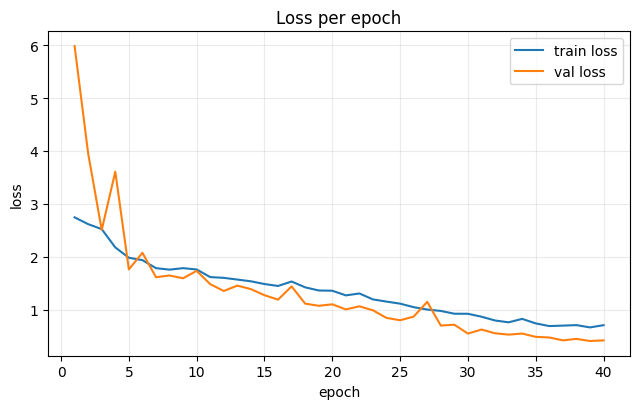

Epoch 40/40  train loss 0.7104 acc 0.7391 | val loss 0.4228 acc 0.8271  (best val acc 0.8346)
Best val acc: 0.8345864661654135 
Saved best checkpoint -> model\models\mbv2_dli14_best.pth


In [11]:
# === TRAIN + LIVE LOSS PLOT (per-epoch) ===
import torch, torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from pathlib import Path

# Reuse your globals if already set; otherwise fall back to sane defaults
device      = torch.device('cpu')
EPOCHS      = int(globals().get('EPOCHS', 40))
LR          = float(globals().get('LR', 0.05))
MODEL_DIR   = Path('model') if Path('model').exists() else Path('.')
OUT_DIR     = MODEL_DIR/'models'; OUT_DIR.mkdir(parents=True, exist_ok=True)
REPO        = str(globals().get('REPO', 'dli14')).lower()

# Use existing model/loaders/criterion/optimizer/scheduler if defined
model = globals().get('model', model).to(device)  # assumes you've already built MobileNetV2
loaders = globals().get('loaders', loaders)       # expects loaders['train'] and loaders['val']

criterion = globals().get('criterion', nn.CrossEntropyLoss())
optimizer = globals().get('optimizer', SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=4e-5))
scheduler = globals().get('scheduler', CosineAnnealingLR(optimizer, T_max=EPOCHS))

best_acc = 0.0
ckpt_path = OUT_DIR / f'mbv2_{REPO}_best.pth'

history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

def run_epoch(dl, train=True):
    if train: model.train()
    else:     model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in tqdm(dl, leave=False):
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            loss.backward(); optimizer.step()
        else:
            with torch.no_grad():
                out = model(x)
                loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum/max(1,total), correct/max(1,total)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(loaders['train'], train=True)
    va_loss, va_acc = run_epoch(loaders['val'],   train=False)
    scheduler.step()

    # record
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)

    # save best
    if va_acc >= best_acc:
        best_acc = va_acc
        torch.save({'model': model.state_dict(),
                    'classes': globals().get('CLASSES', [])}, ckpt_path)

    # ---- live plot: loss per epoch ----
    clear_output(wait=True)
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(6.5,4.2))
    plt.plot(epochs, history["train_loss"], label='train loss')
    plt.plot(epochs, history["val_loss"],   label='val loss')
    plt.title('Loss per epoch'); plt.xlabel('epoch'); plt.ylabel('loss')
    plt.legend(); plt.grid(True, alpha=.25); plt.tight_layout()
    display(plt.gcf())
    plt.close()

    # also print a concise line with metrics
    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}  "
          f"(best val acc {best_acc:.4f})")

# (optional) persist history for later plotting
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(OUT_DIR/'training_history.csv', index=False)
except Exception:
    pass

print("Best val acc:", best_acc, "\nSaved best checkpoint ->", ckpt_path)


## 10) Graph Accuracy Plot: Training vs Validation 

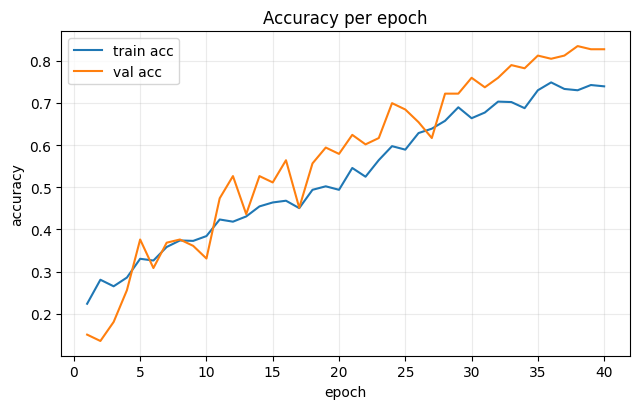

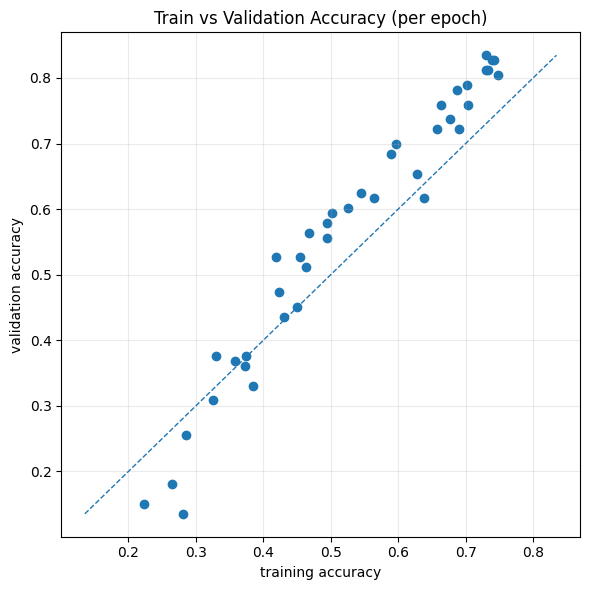

Avg gen gap (train - val): -0.0414   |   Max gap: 0.1452


In [12]:
# === ACCURACY PLOTS: line (per epoch) + XY (train vs val) ===

import os, sys, subprocess
from pathlib import Path

# make sure matplotlib/pandas are available (installs once if missing)
try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas"])
    import matplotlib.pyplot as plt
    import pandas as pd

OUT_DIR = Path("model/models") if Path("model").exists() else Path("models")

# 1) get history (prefer in-memory; else load CSV saved by training cell)
hist = None
if "history" in globals() and isinstance(history, dict) and history.get("train_acc"):
    hist = history
elif (OUT_DIR/"training_history.csv").exists():
    df = pd.read_csv(OUT_DIR/"training_history.csv")
    cols = [c for c in ["train_acc","val_acc","train_loss","val_loss"] if c in df.columns]
    hist = {k: df[k].tolist() for k in cols}

if not hist or "train_acc" not in hist or "val_acc" not in hist:
    raise SystemExit("No accuracy history found. Run training (or save training_history.csv) first.")

epochs = range(1, len(hist["train_acc"])+1)

# 2) line chart: accuracy vs epoch
plt.figure(figsize=(6.5,4.2))
plt.plot(epochs, hist["train_acc"], label="train acc")
plt.plot(epochs, hist["val_acc"],   label="val acc")
plt.title("Accuracy per epoch")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# 3) XY scatter: train acc (X) vs val acc (Y) + y=x line
import numpy as np
ta = np.array(hist["train_acc"], dtype=float)
va = np.array(hist["val_acc"],   dtype=float)

plt.figure(figsize=(6.0,6.0))
plt.scatter(ta, va)
mn = float(min(ta.min(), va.min()))
mx = float(max(ta.max(), va.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)  # y = x reference
plt.xlabel("training accuracy")
plt.ylabel("validation accuracy")
plt.title("Train vs Validation Accuracy (per epoch)")
plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# (optional) quick text summary
gap = (ta - va)
print(f"Avg gen gap (train - val): {gap.mean():.4f}   |   Max gap: {gap.max():.4f}")


## 11) Test set evaluation

In [13]:
from torch.utils.data import DataLoader
from torchvision import datasets
if (DST/'test').exists():
    test_ds = datasets.ImageFolder(DST/'test', transform=val_tfms)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval(); correct=0; total=0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)
            correct += (pred==y).sum().item(); total += x.size(0)
    print('Test accuracy:', correct/max(1,total))
else:
    print('No test split found — skipping.')

C:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test accuracy: 0.8371212121212122


## 12) Export TorchScript (.pt) and ONNX (.onnx)

In [14]:
model.eval()
dummy = torch.randn(1,3,INPUT_SIZE,INPUT_SIZE).to(device)

# TorchScript
ts = torch.jit.trace(model, dummy)
ts_path = MODEL_DIR/'models'/f'mobilenetv2_{REPO}.pt'
ts.save(str(ts_path))
print('Saved TorchScript ->', ts_path.resolve())

Saved TorchScript -> C:\aziztebbeng\2025-CP_Fishfresh\model\model\models\mobilenetv2_dli14.pt


In [20]:
model.eval()
dummy = torch.randn(1,3,INPUT_SIZE,INPUT_SIZE).to(device)

# TorchScript
ts = torch.jit.trace(model, dummy)
ts_path = MODEL_DIR/'models'/f'mobilenetv2_{REPO}.pt'
ts.save(str(ts_path))
print('Saved TorchScript ->', ts_path.resolve())

Saved TorchScript -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\mobilenetv2_dli14.pt


## 13) EXPORTING TO ONNX FROM TOURCHSCRIPT .PT WITH A HUMAN READABLE TIMESTAMP

In [19]:
# --- ONNX export (legacy exporter) with timestamped filename ---
import torch
from pathlib import Path
from datetime import datetime

model.eval().cpu()
dummy = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)  # CPU dummy

# Define your model directory directly
MODEL_DIR = Path(r"C:\aziztebbeng\2025-CP_Fishfresh\model")

# Build timestamp: "Sept_13_10-20_am"
dt = datetime.now()
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sept",10:"Oct",11:"Nov",12:"Dec"}
hour12 = dt.hour % 12 or 12
ampm = "am" if dt.hour < 12 else "pm"
stamp = f"{month_map[dt.month]}_{dt.day}_{hour12}-{dt.minute:02d}_{ampm}"

onnx_path = MODEL_DIR / "models" / f"mobilenetv2_{REPO}_{stamp}.onnx"

torch.onnx.export(
    model, dummy, str(onnx_path),
    input_names=['input'], output_names=['logits'],
    opset_version=13,
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    dynamo=False,  # force legacy exporter (no extra deps)
    # If you want dynamic batch on legacy path, uncomment:
    # dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
)

print("Saved ONNX ->", onnx_path.resolve())


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15720\742141658.py:21: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Saved ONNX -> C:\aziztebbeng\2025-CP_Fishfresh\model\models\mobilenetv2_dli14_Oct_6_5-32_am.onnx


---
### Notes & References
- **d-li14** repo: README usage and imagenet training flags (cosine LR, 0.05 LR, 4e-5 WD, 224px) — we mirror those defaults here.
- **tonylins** repo: canonical MobileNetV2 module; we import it directly and set `num_classes`.
- Normalization uses ImageNet mean/std; resize/crop = 224.
- You can raise `EPOCHS`, use label smoothing, or RandAugment to push accuracy if needed.


In [ ]:
# Run this IN THE NOTEBOOK so it installs into the current kernel
import sys, subprocess
print("Kernel python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U",
                       "onnx>=1.15,<1.18", "onnxscript>=0.1.0,<0.2.0"])